In [1]:
# !pip install matplotlib


In [2]:
import torch.nn as nn

In [3]:

model = nn.Sequential(
          nn.Conv2d(3, 10000, 3), # мистический свёрточный слой
          nn.ReLU(),
          nn.Flatten(),
          nn.Linear(10000, 10),
          nn.Softmax(dim=1),
        )

print("Количество весов нейросети = ", sum(p.numel() for p in model.parameters()))

Количество весов нейросети =  380010


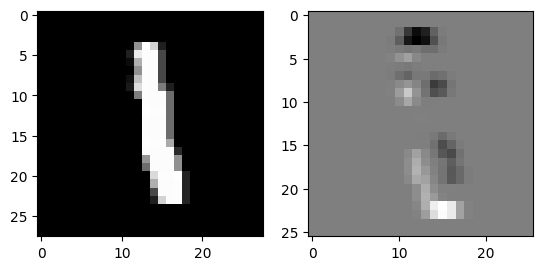

In [20]:
from matplotlib import pyplot as plt
import torch
from PIL import Image
from torchvision.transforms.functional import to_tensor

image = Image.open("data/img.png")
image_tensor = to_tensor(image) # тензор [1, 28, 28]

# добавляем ещё одно измерение, чтобы получить [1, 1, 28, 28]
image_tensor = image_tensor.unsqueeze(0) 

kernel = torch.Tensor([[[[3, 10, 3], 
                         [0, 0, 0], 
                         [-3, -10, -3]]]]) # некий фильтр размерности [1, 1, 3, 3]

result = torch.nn.functional.conv2d(image_tensor, kernel) 


fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray') 

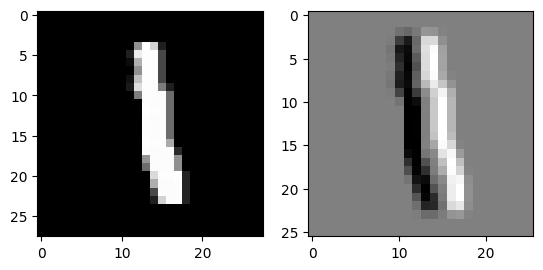

In [7]:
kernel = torch.Tensor([[[[3,  0, -3], 
                         [10, 0, -10], 
                         [3,  0, -3]]]]) # некий фильтр размерности [1, 1, 3, 3]

result = torch.nn.functional.conv2d(image_tensor, kernel) 


fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image, cmap = 'gray')

plt.subplot(1, 2, 2)
plt.imshow(result[0][0], cmap = 'gray') 

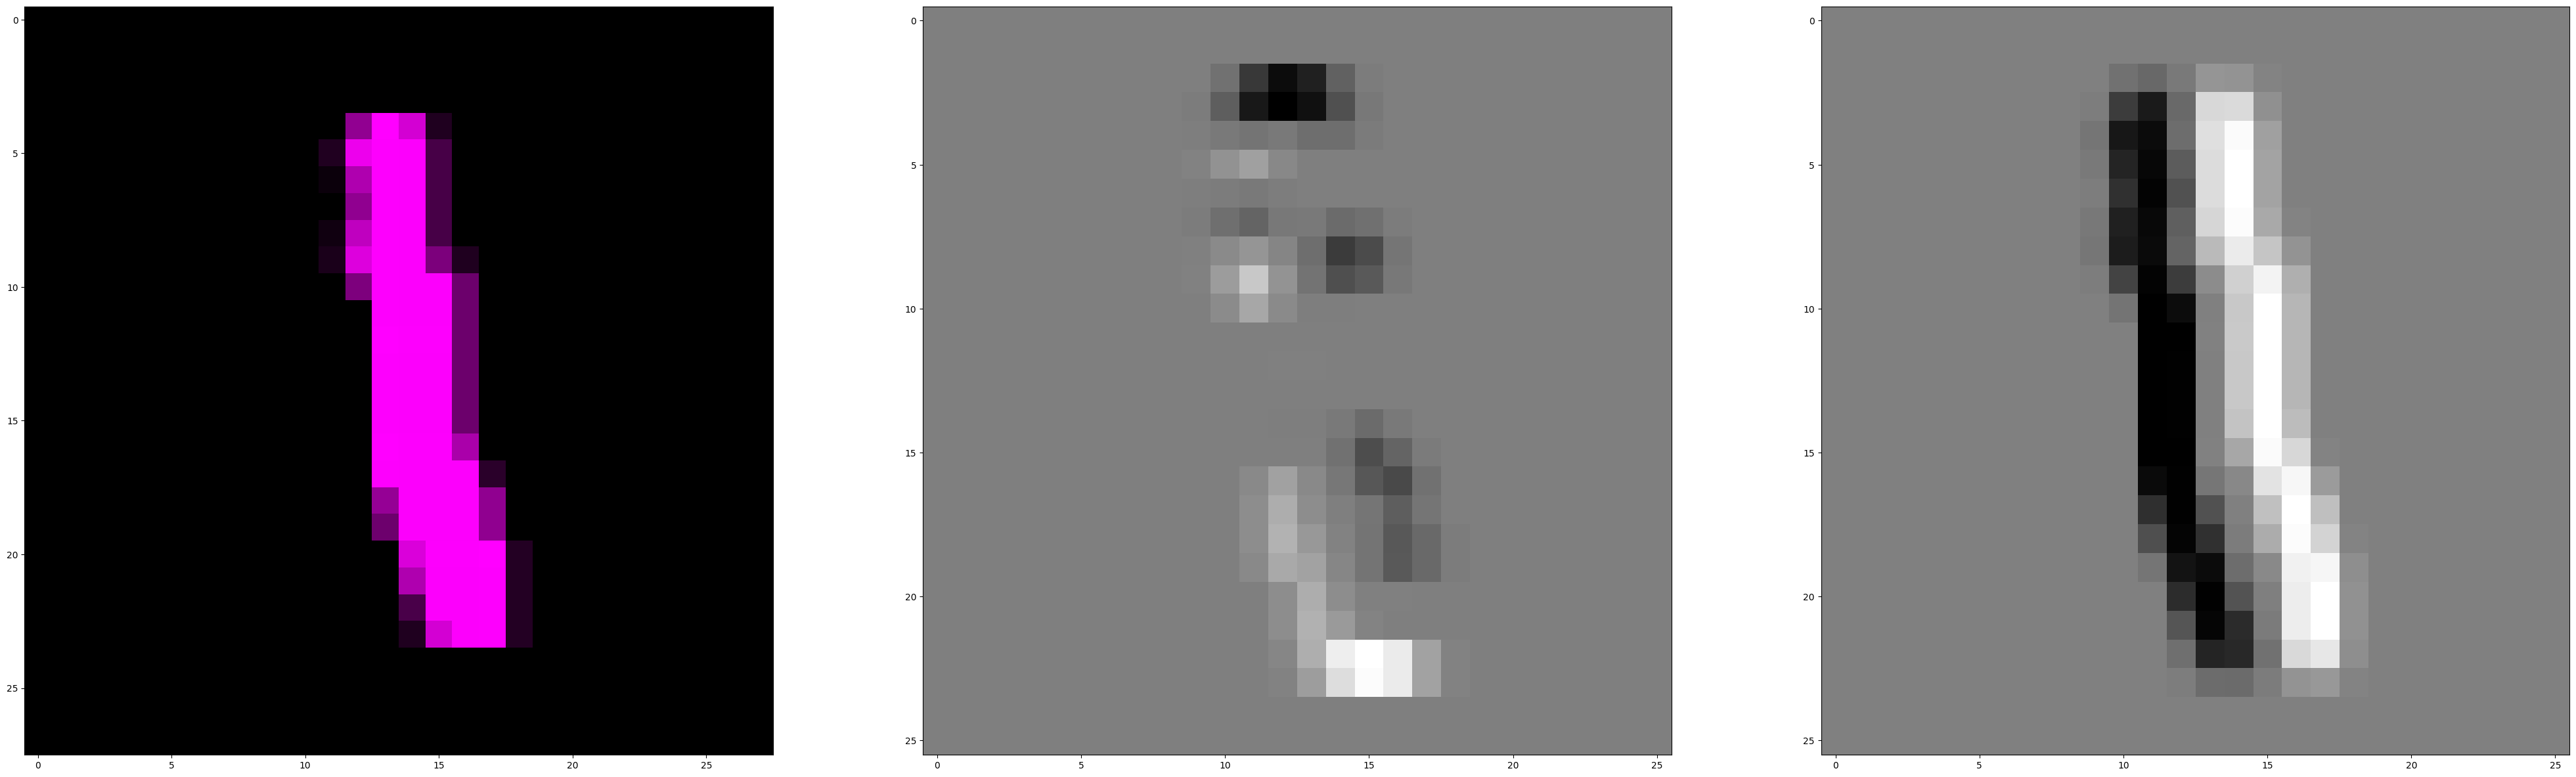

In [21]:
import numpy as np

image = Image.open("data/img_colored.png")
image_tensor = to_tensor(image) # тензор [1, 28, 28]

# добавляем ещё одно измерение, чтобы получить [1, 1, 28, 28]
image_tensor = image_tensor.unsqueeze(0) 


kernel_horizontal = np.array([[3,  10,  3],
                              [0,  0,   0],
                              [-3, -10, -3]])
kernel_vertical = np.array([[3,  0, -3],
                            [10, 0, -10],
                            [3,  0, -3]])

kernel_3D = np.tile(kernel_horizontal, (3, 1, 1)) # трёхмерный фильтр горизонтальных линий
kernel_3D = torch.Tensor(kernel_3D) # преобразование в pytorch-тензор 
kernel_3D = kernel_3D.unsqueeze(0)
result_horizontal = torch.nn.functional.conv2d(image_tensor, kernel_3D) 

kernel_3D = np.tile(kernel_vertical, (3, 1, 1))
kernel_3D = torch.Tensor(kernel_3D) 
kernel_3D = kernel_3D.unsqueeze(0)
result_vertical = torch.nn.functional.conv2d(image_tensor, kernel_3D) 

fig = plt.figure(figsize=(50,50))
plt.subplot(1, 3, 1)
plt.imshow(image)

plt.subplot(1, 3, 2)
plt.imshow(result_horizontal[0][0], cmap = 'gray') 

plt.subplot(1, 3, 3)
plt.imshow(result_vertical[0][0], cmap = 'gray') 

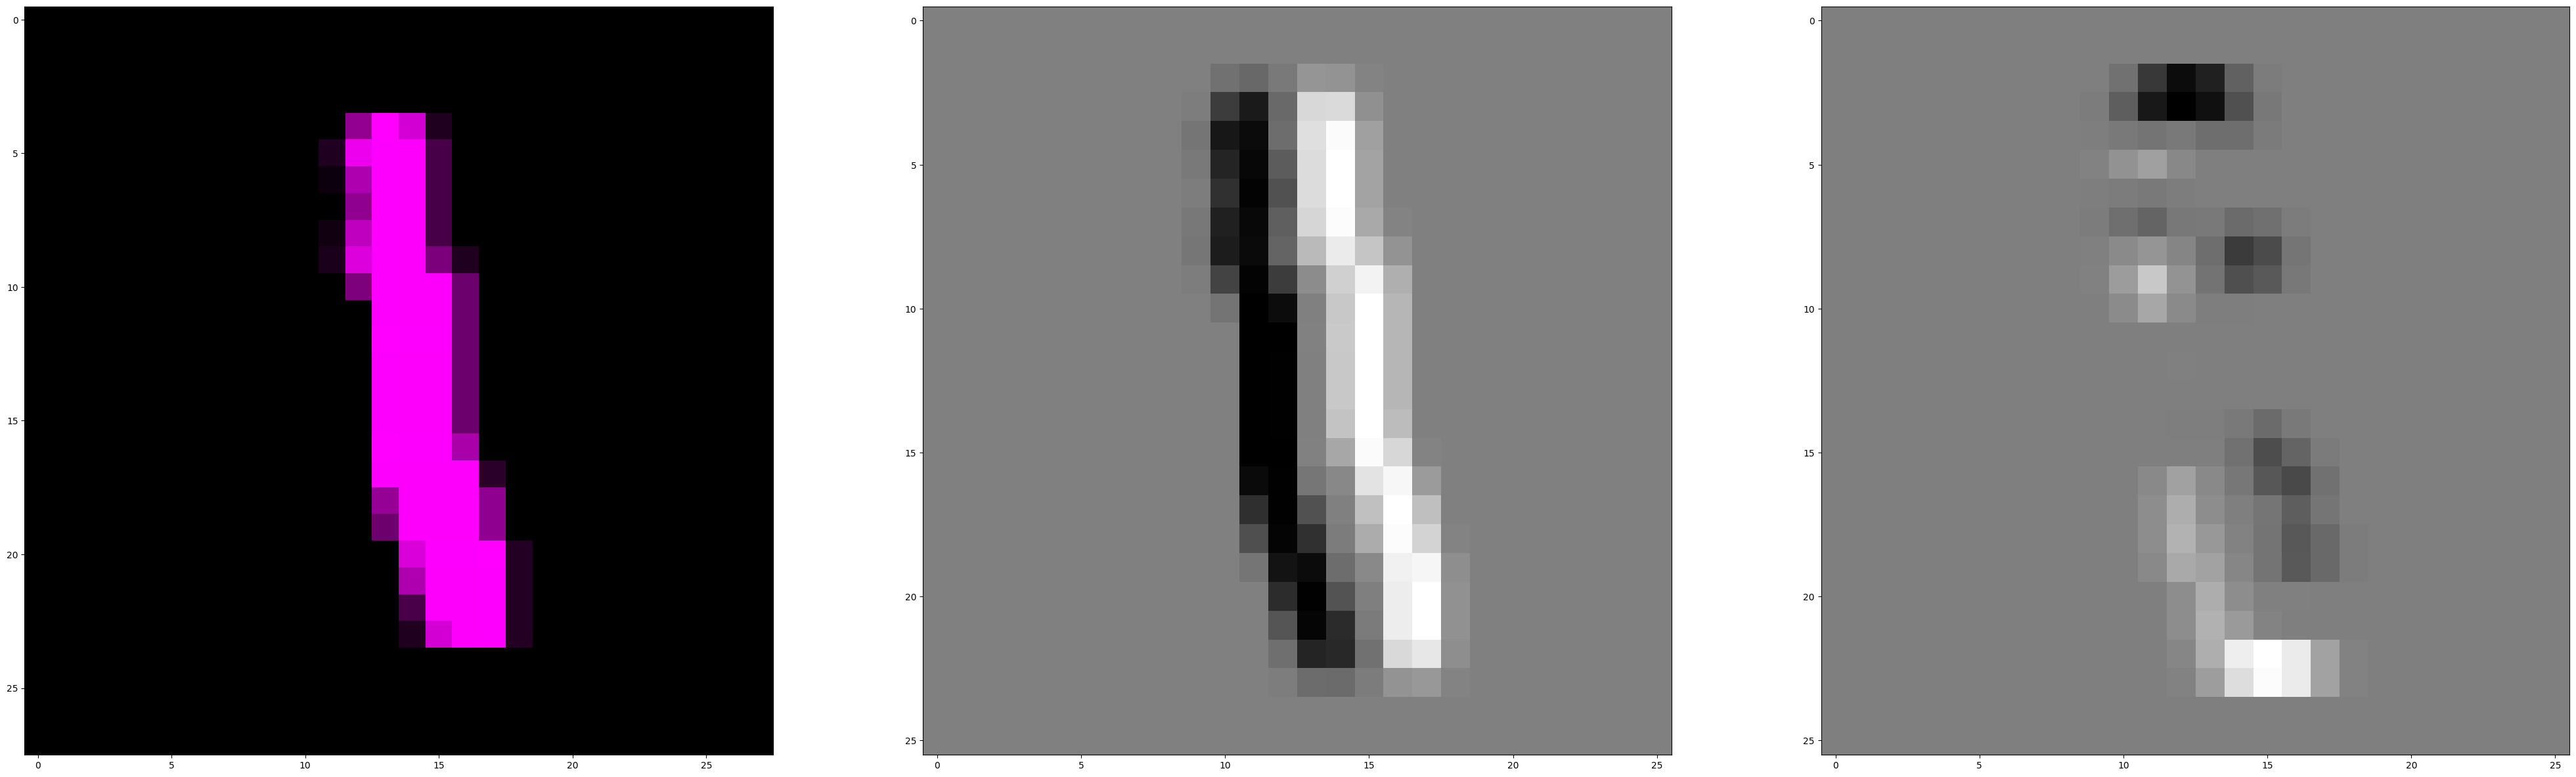

In [23]:
from PIL import Image
import torch
import numpy as np
from matplotlib import pyplot as plt
from torchvision.transforms.functional import to_tensor

image = Image.open("data/img_colored.png")
image_tensor = to_tensor(image) # тензор [1, 3, 28, 28]
# добавлено ещё одно измерение, чтобы получить [1, 3, 28, 28]
image_tensor = image_tensor.unsqueeze(0)

kernel_v = np.array([[3, 0, -3], # обычный фильтр вертикальных линий
                     [10, 0, -10],
                     [3, 0, -3]])

kernel_h = np.array([[3, 10, 3], # обычный фильтр горизонтальных линий
                     [0, 0, 0],
                     [-3, -10, -3]])

kernel_v_3D = np.tile(kernel_v, (3, 1, 1)) # трёхмерный фильтр вертикальных линий

kernel_h_3D = np.tile(kernel_h, (3, 1, 1)) # трёхмерный фильтр горизонтальных линий

kernels = torch.Tensor(np.stack([kernel_v_3D, kernel_h_3D])) # тензор с фильтрами

result = torch.nn.functional.conv2d(image_tensor, kernels)

# визуализация
fig = plt.figure(figsize=(50,50))
plt.subplot(1, 3, 1)
plt.imshow(image)

plt.subplot(1, 3, 2)
plt.imshow(result[0][0], cmap='gray') # карта признака вертикальных линий

plt.subplot(1, 3, 3)
plt.imshow(result[0][1], cmap='gray') # карта признака горизонтальных линий

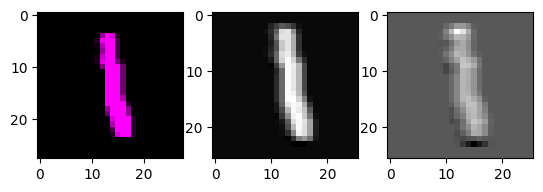

In [24]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from torchvision.transforms.functional import to_tensor
import torch.nn as nn

image = Image.open("data/img_colored.png")
image_tensor = to_tensor(image)
image_tensor = image_tensor.unsqueeze(0)

# Создание слоя для обработки трёхканального изображения
# двумя фильтрами
# размером 3х3
conv_layer = nn.Conv2d(3, 2, 3)

# Слой в pytorch - это функция
# Применение функции к входному изображению
# .detach() позволяет осуществить операцию
# и получить конкретные значения из pytorch-тензора.
result = conv_layer(image_tensor).detach()

# визуализация
fig = plt.figure()
plt.subplot(1, 3, 1)
plt.imshow(image)

plt.subplot(1, 3, 2)
plt.imshow(result[0][0], cmap='gray') # карта признака 1

plt.subplot(1, 3, 3)
plt.imshow(result[0][1], cmap='gray') # карта признака 2

In [25]:
conv_layer.weight

Parameter containing:
tensor([[[[-1.2272e-01, -6.5076e-02,  1.5469e-01],
          [ 1.8255e-01,  4.1903e-02,  7.1717e-02],
          [ 1.3678e-02,  1.3166e-01,  3.5950e-02]],

         [[-2.0198e-02,  2.0837e-02,  1.1439e-01],
          [-1.0773e-01,  1.1334e-02,  9.2488e-02],
          [-4.9351e-02, -1.1022e-01, -1.4585e-01]],

         [[ 1.3458e-01,  1.5247e-02, -1.4377e-01],
          [ 1.7699e-01,  1.9048e-01, -1.2622e-01],
          [ 1.8637e-01, -7.7671e-02,  1.4005e-01]]],


        [[[-1.0375e-01, -6.1456e-02, -1.6226e-01],
          [ 3.8082e-02,  1.4978e-01,  1.7953e-01],
          [ 1.8125e-01,  5.9942e-03, -2.0040e-02]],

         [[-1.3674e-01,  1.1531e-01, -1.7936e-01],
          [ 1.4811e-01,  1.4146e-01,  2.3178e-02],
          [ 7.8392e-05,  3.9977e-02,  9.5517e-02]],

         [[-9.7869e-02, -1.1672e-01, -6.2234e-02],
          [ 1.5323e-01,  1.1909e-01, -8.5800e-04],
          [ 1.3067e-01,  9.2306e-02,  1.7618e-01]]]], requires_grad=True)

In [26]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from torchvision.transforms.functional import to_tensor
import torch.nn as nn

image = Image.open("data/img_colored.png")
image_tensor = to_tensor(image)
image_tensor = image_tensor.unsqueeze(0)

conv_layer = nn.Conv2d(3, 20, 3)
result = conv_layer(image_tensor).detach()

print("Размерность тензора: ", result.shape)

Размерность тензора:  torch.Size([1, 20, 26, 26])


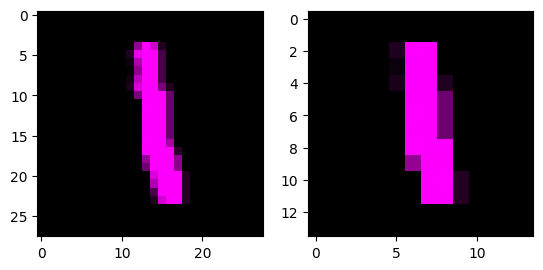

In [28]:
from PIL import Image
from matplotlib import pyplot as plt
import numpy as np
from torchvision.transforms.functional import to_tensor
import torch.nn as nn

image = Image.open("data/img_colored.png")
image_tensor = to_tensor(image)
# добавлено ещё одно измерение, чтобы получить [1, 3, 28, 28]
image_tensor = image_tensor.unsqueeze(0)

pool_layer = nn.MaxPool2d(2) # объявление слоя пулинга с окном 2х2, страйдом 2

result = pool_layer(image_tensor).detach()

# визуализация
fig = plt.figure()
plt.subplot(1, 2, 1)
plt.imshow(image)

plt.subplot(1, 2, 2)
# результат - трёхканальный тензор [3, 14, 14]
# plt.imshow ожидает изображение в формате [высота, ширина, количество каналов]
# поэтому используется permute, чтобы привести [3, 14, 14] к [14, 14, 3]
plt.imshow(result[0].permute(1, 2, 0))